In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('zdalna.xlsx')

In [3]:
df.shape

(966, 56)

In [50]:
df.drop('Sygnatura czasowa', axis=1, inplace=True)

In [51]:
df.to_csv('zdalna1.csv',index=False)

In [52]:
df = pd.read_csv('zdalna1.csv' )

In [53]:
prefix_dict1 = {
    # Perceived Usefulness
    "Jak ocenia Pan/ Pani użyteczność nauki zdalnej?": "PU",
    
    # Perceived Ease of Use
    "Jak ocenia Pan/ Pani łatwość nauki w trybie zdalnym.": "PEOU"
}

prefix_dict2 = {
    # Behavioral Intention
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Jeżeli w przyszłości będę rozważał podjęcie studiów, to w pierwszej kolejności wezmę pod uwagę studia w trybie zdalnym]": "BI1",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Będę sugerować innym wybór studiów w trybie zdalnym]": "BI2",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Oferta studiów w trybie zdalnym będzie w przyszłości czynnikiem który może zadecydować o podjęciu przeze mnie studiów na danym kierunku]": "BI3",
    
    # Engagement
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Sumiennie uczestniczę we wszystkich zajęciach zdalnych]": "ENG1",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Regularnie odsłuchuję nagrania z zajęć zdalnych]": "ENG2",
    
    # Negative experiences
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Przez naukę zdalna tracę możliwość kontaktu z innymi studentami]": "NEG1",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Przy nauce zdalnej weryfikacja wiedzy studentów (egzaminy, kolokwia) jest fikcją]": "NEG2",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Zdalna forma nauki jest dla mnie męcząca ze względu na konieczność długiego siedzenia przed komputerem]": "NEG3",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Nauczanie zdalne rozleniwia]": "NEG4",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Nauka zdalna jest dla mnie trudna z powodu słabej jakości połączenia internetowego]": "NEG5",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Forma zdalna zajęć utrudnia mi skupienie się na materiale przekazywanym przez prowadzącego]": "NEG6",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Tryb zdalny demotywuje mnie do nauki]": "NEG7",
    
    # Positive effects / benefits
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Mam pozytywne nastawienie do nauki zdalnej]": "POS1",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Studiowanie w trybie online daje mi wymierne oszczędności finansowe]": "POS2",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Dzięki tej technologii odsłuchuję później nagrania z zajęć]": "POS3",
    "Proszę ocenić na skali od 1-5 poniższe twierdzenia. Gdzie 1- oznacza całkowicie się nie zgadzam, a 5- całkowicie się zgadzam [Nauka w trybie zdalnym umożliwia mi jednoczesne wykonywanie różnych czynności (np. praca i nauka)]": "POS4",
    
}

In [54]:
new_columns = {}
for original, prefix in prefix_dict1.items():
    matching_cols = [col for col in df.columns if col.startswith(original)]
    for i, col in enumerate(matching_cols, 1):
        new_columns[col] = f"{prefix}{i}"

df.rename(columns=new_columns, inplace=True)

new_columns = {}
for original, prefix in prefix_dict2.items():
    matching_cols = [col for col in df.columns if col.startswith(original)]
    for col in matching_cols:
        new_columns[col] = f"{prefix}"

df.rename(columns=new_columns, inplace=True)

In [55]:
prefix_dict3 = {
        'W jakim trybie aktualnie Pan/ Pani studiuje? ':'study mode',
        'Proszę wskazać jeden wariant który najlepiej charakteryzuje Pana/ Pani sytuację.': 'employment',
       'W jakim trybie Pan/ Pani studiuje?': 'full-time-study',
       'Proszę wskazać poziom obecnie odbywanych przez Pana/ Panią studiów.':'study level',
       'Jaki kierunek studiuje Pan/ Pani w Akademii Ekonomiczno-Humanistycznej w Warszawie?':'study program',
       'Proszę wskazać swój wiek': 'age',
    'Proszę wskazać swoją płeć':'gender',
    'Proszę zaznaczyć na poniższej liście wszystkie cechy które pasują do Pana/ Pani sytuacji?  [Mieszkam poza granicami Polski]': 'abroad',
    'Proszę zaznaczyć na poniższej liście wszystkie cechy które pasują do Pana/ Pani sytuacji?  [Mieszkam w małej miejscowości z dala od dużego ośrodka akademickiego]': 'remote_area',
    'Proszę zaznaczyć na poniższej liście wszystkie cechy które pasują do Pana/ Pani sytuacji?  [Opiekuję się dzieckiem/ dziećmi]': 'has_children',
    'Proszę zaznaczyć na poniższej liście wszystkie cechy które pasują do Pana/ Pani sytuacji?  [Opiekuję się osobą chorą i/lub niedołężną]': 'caregiver',
    'Proszę zaznaczyć na poniższej liście wszystkie cechy które pasują do Pana/ Pani sytuacji?  [Jestem osobą chorą i/ lub niepełnosprawną, której ciężko samodzielnie dojeżdżać np. do pracy i/lub na zajęcia]': 'health_limitation',

    'Proszę wskazać swoją narodowość:': 'nationality',

    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie dyplomu]': 'goal_diploma',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie wiedzy, umiejętności które będę mógł zastosować w życiu zawodowym lub prywatnym]': 'goal_skills',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie pretekstu do wyprowadzki z domu rodzinnego i lub prowadzenie]': 'goal_move_out',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [życia towarzyskiego]': 'goal_social_life',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Znalezienie partnerki/ partnera]': 'goal_partner',

    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie dyplomu].1': 'goal_diploma_2',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie wiedzy, umiejętności które będę mógł zastosować w życiu zawodowym lub prywatnym].1': 'goal_skills_2',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie pretekstu do wyprowadzki z domu rodzinnego i lub prowadzenie].1': 'goal_move_out_2',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [życia towarzyskiego].1': 'goal_social_life_2',
    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Znalezienie partnerki/ partnera].1': 'goal_partner_2',

    'Ostatnie pytanie o cel studiów. Proszę zaznaczyć na ile zgadza się Pan/ Pani z poniższymi twierdzeniami dotyczącymi celu podjętych przez Pana/ Panią studiów. [Zdobycie możliwości podjęcia pracy na terenie Unii Europejskiej]': 'goal_eu_job'
}

In [56]:
df.rename(columns=prefix_dict3, inplace=True)

In [57]:
df.to_csv('zdalna2.csv', index=False)

In [9]:
df= pd.read_csv('zdalna2.csv')

In [11]:
# Przemianowanie i przekodowanie wartości studia hybrydowe, czy w pełni zdalne
col = 'study mode'
df[col] = df[col].replace({
    'Wszystkie zajęcia odbywają się na terenie uczelni':100,
    'Część zajęć odbywa się na terenie uczelni a część za pośrednictwem Internetu': 0,
    'Wszystkie zajęcia odbywają się online': 1
})

C:\Users\User\AppData\Local\Temp\ipykernel_11988\1754029632.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [12]:
# Przemianowanie i przekodowanie wartości kolumny dotyczącej pracy
col = 'employment'
df[col] = df[col].replace({
    'Studiuję i nie pracuję': 0,
    'Studiuję i pracuję w niepełnym wymiarze godzin': 1,
    'Studiuję i pracuję w pełnym wymiarze godzin':2
})

C:\Users\User\AppData\Local\Temp\ipykernel_11988\1440636893.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [13]:
col = 'full-time-study'
df[col] = df[col].replace({
    'tryb niestacjonarny (zaoczny)': 0,
    'tryb stacjonarny (dzienny)': 1,
})

C:\Users\User\AppData\Local\Temp\ipykernel_11988\3362819150.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [14]:
col = 'study level'
df[col] = df[col].replace({
    'Jednolite studia magisterskie': 'long-master',
    'Studia licencjackie': 'bachelor',
    'Studia uzupełniające magisterskie (2-letnie)' : "master"
})

In [15]:
study_program_translation = {
    'Psychologia': 'Psychology',
    'Filologia angielska': 'English Philology',
    'Zarządzanie': 'Management',
    'Informatyka': 'Computer Science',
    'Dietetyka': 'Dietetics',
    'Politologia': 'Political Science',
    'Finanse i rachunkowość': 'Finance and Accounting',
    'Kosmetologia': 'Cosmetology',
    'Administracja': 'Public Administration',
    'Prawo': 'Law',
    'Filologia germańska': 'German Philology',
    'Nowe media i public relations': 'New Media and Public Relations',
    'Fashion Design': 'Fashion Design',
    'Cyberbezpieczeństwo': 'Cybersecurity',
    'Bezpieczeństwo i stosunki międzynarodowe': 'Security and International Relations'
}
df['study program'] = df['study program'].replace(study_program_translation)

In [16]:
col = 'age'
df[col] = df[col].replace({
    '15-18 lat':0,
    '19-24 lata': 1,
    '25-29 lat':2,
    '30-39 lat': 3,
    '40 lat i więcej':4
})

C:\Users\User\AppData\Local\Temp\ipykernel_11988\2819250023.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [17]:
col = 'gender'
df[col] = df[col].replace({
    'Kobieta':0,
    'Mężczyzna': 1, 
})

C:\Users\User\AppData\Local\Temp\ipykernel_11988\794498814.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [18]:
cols = ['abroad', 'remote_area', 'has_children', 'caregiver', 'health_limitation']
for col in cols:
    df[col] = df[col].replace({
    'Nie':0,
    'Tak': 1, 
    })

C:\Users\User\AppData\Local\Temp\ipykernel_11988\3251786494.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [19]:
df = df.rename(columns={'nationality': 'is_Polish'})
df['is_Polish'] = (df['is_Polish'] == 'Polska').astype(int)

In [20]:
df.to_csv('zdalna3.csv', index=False)

In [21]:
df['goal_diploma'].unique()

array(['5 - Całkowicie zgadzam się', '1', '4 - Zgadzam się', nan,
       '3 - Nie mam zdania', '2 - Nie zgadzam się'], dtype=object)

In [22]:
cols = ['goal_diploma', 'goal_skills', 'goal_move_out', 'goal_social_life', 'goal_partner', 
        'goal_diploma_2', 'goal_skills_2', 'goal_move_out_2', 'goal_social_life_2','goal_partner_2', 'goal_eu_job']
for col in cols:
    
    df[col] = df[col].replace({
        '5 - Całkowicie zgadzam się':5,
        '1':1,
        '4 - Zgadzam się':4,
        '3 - Nie mam zdania':3,
        '2 - Nie zgadzam się':2 
    })

C:\Users\User\AppData\Local\Temp\ipykernel_11988\920032118.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [23]:
cols = ['goal_diploma', 'goal_skills', 'goal_move_out', 'goal_social_life', 'goal_partner']

for col in cols:
    col2 = f"{col}_2"
    df[col] = df[col].fillna(df[col2])

In [24]:
df = df.drop(columns=['goal_diploma_2', 'goal_skills_2', 'goal_move_out_2', 'goal_social_life_2','goal_partner_2'])

In [25]:
df.to_csv('zdalna4.csv', index=False)

In [4]:
df= pd.read_csv('zdalna4.csv')


In [5]:
df['study mode'].unique()

array([  0,   1, 100])

In [6]:
count_100 = (df['study mode'] == 100).sum()
print(count_100)

17


In [8]:
count_missing = df['gender'].isna().sum()
print(count_missing)

25


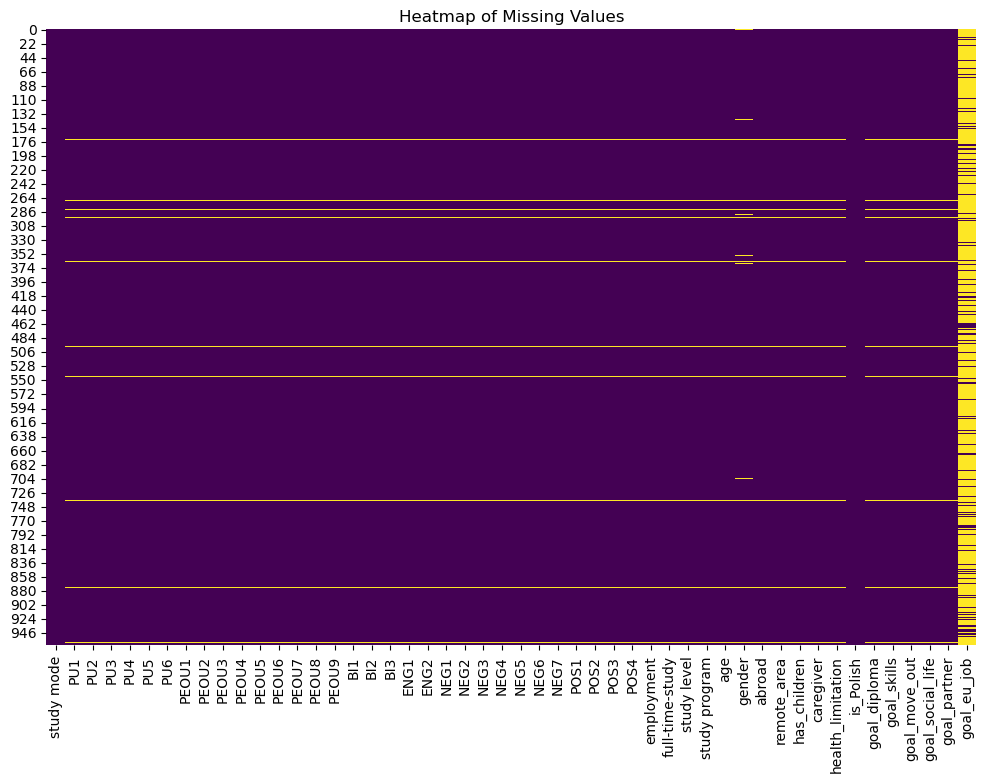

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rysujemy heatmapę braków
plt.figure(figsize=(12,8))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title("Heatmap of Missing Values")
plt.show()

In [86]:
print(df.shape)

(966, 50)


In [28]:
df = df.drop('goal_eu_job', axis=1)
print(df.shape)

(966, 49)


In [29]:
# Usuwamy wiersze, gdzie brak >50% wartości
df2 = df[df.isna().mean(axis=1) <= 0.5]
print(df2.shape)

(949, 49)


In [30]:
df3 = df.dropna()
print(df3.shape)

(941, 49)


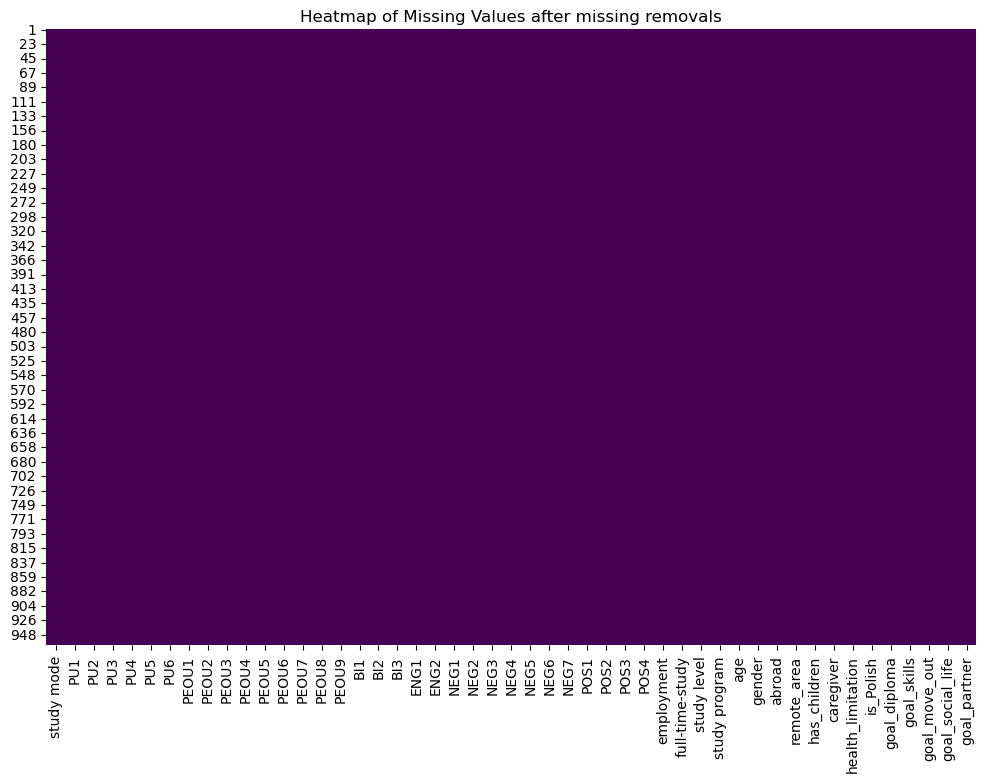

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rysujemy heatmapę braków
plt.figure(figsize=(12,8))
sns.heatmap(df3.isna(), cbar=False, cmap='viridis')
plt.title("Heatmap of Missing Values after missing removals")
plt.show()

In [32]:
df3.to_csv('zdalna5.csv', index=False)

In [33]:
import pandas as pd
df = pd.read_csv('zdalna5.csv')

In [34]:
df.columns

Index(['study mode', 'PU1', 'PU2', 'PU3', 'PU4', 'PU5', 'PU6', 'PEOU1',
       'PEOU2', 'PEOU3', 'PEOU4', 'PEOU5', 'PEOU6', 'PEOU7', 'PEOU8', 'PEOU9',
       'BI1', 'BI2', 'BI3', 'ENG1', 'ENG2', 'NEG1', 'NEG2', 'NEG3', 'NEG4',
       'NEG5', 'NEG6', 'NEG7', 'POS1', 'POS2', 'POS3', 'POS4', 'employment',
       'full-time-study', 'study level', 'study program', 'age', 'gender',
       'abroad', 'remote_area', 'has_children', 'caregiver',
       'health_limitation', 'is_Polish', 'goal_diploma', 'goal_skills',
       'goal_move_out', 'goal_social_life', 'goal_partner'],
      dtype='object')

In [35]:
# Lista kolumn do konwersji
columns_to_convert = ['study mode', 'PU1', 'PU2', 'PU3', 'PU4', 'PU5', 'PU6', 'PEOU1',
       'PEOU2', 'PEOU3', 'PEOU4', 'PEOU5', 'PEOU6', 'PEOU7', 'PEOU8', 'PEOU9',
       'BI1', 'BI2', 'BI3', 'ENG1', 'ENG2', 'NEG1', 'NEG2', 'NEG3', 'NEG4',
       'NEG5', 'NEG6', 'NEG7', 'POS1', 'POS2', 'POS3', 'POS4', 'employment',
       'full-time-study','age', 'gender',
       'abroad', 'remote_area', 'has_children', 'caregiver',
       'health_limitation', 'is_Polish', 'goal_diploma', 'goal_skills',
       'goal_move_out', 'goal_social_life', 'goal_partner']

# Jednolinijkowa konwersja wszystkich wybranych kolumn na integer
df[columns_to_convert] = df[columns_to_convert].astype(int)

In [36]:
columns_to_encode = ['study level', 'study program']  # <- wstaw swoje kolumny

for col in columns_to_encode:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)

In [37]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

print("Kolumny binarne:", binary_cols)

# Konwersja tych kolumn na bool
df[binary_cols] = df[binary_cols].astype(bool)

Kolumny binarne: ['study mode', 'full-time-study', 'gender', 'abroad', 'remote_area', 'has_children', 'caregiver', 'health_limitation', 'is_Polish', 'study level_bachelor', 'study level_long-master', 'study level_master', 'study program_Computer Science', 'study program_Cosmetology', 'study program_Cybersecurity', 'study program_Dietetics', 'study program_English Philology', 'study program_Fashion Design', 'study program_Finance and Accounting', 'study program_German Philology', 'study program_Law', 'study program_Management', 'study program_New Media and Public Relations', 'study program_Political Science', 'study program_Psychology', 'study program_Public Administration', 'study program_Security and International Relations']


In [38]:
df.to_csv('zdalna6.csv', index=False)

In [39]:
df.columns

Index(['study mode', 'PU1', 'PU2', 'PU3', 'PU4', 'PU5', 'PU6', 'PEOU1',
       'PEOU2', 'PEOU3', 'PEOU4', 'PEOU5', 'PEOU6', 'PEOU7', 'PEOU8', 'PEOU9',
       'BI1', 'BI2', 'BI3', 'ENG1', 'ENG2', 'NEG1', 'NEG2', 'NEG3', 'NEG4',
       'NEG5', 'NEG6', 'NEG7', 'POS1', 'POS2', 'POS3', 'POS4', 'employment',
       'full-time-study', 'study level', 'study program', 'age', 'gender',
       'abroad', 'remote_area', 'has_children', 'caregiver',
       'health_limitation', 'is_Polish', 'goal_diploma', 'goal_skills',
       'goal_move_out', 'goal_social_life', 'goal_partner',
       'study level_bachelor', 'study level_long-master', 'study level_master',
       'study program_Computer Science', 'study program_Cosmetology',
       'study program_Cybersecurity', 'study program_Dietetics',
       'study program_English Philology', 'study program_Fashion Design',
       'study program_Finance and Accounting',
       'study program_German Philology', 'study program_Law',
       'study program_Manageme

In [ ]:
# Pobranie 